# DCIT407 LAB ASSIGNMENT 2

**Student ID:** 11126586  
**Course:** DCIT407

## Objectives
1. Load multiple images (text-like, landscape-like, and face-like) and apply Canny edge detection.
2. Experiment with threshold pairs: (50,150), (100,200), and (150,300).
3. Compare Canny results with Sobel edge detection.
4. Create a threshold-adjustment user interface using OpenCV trackbars.

## Methodology (Simple Steps I Followed)

1. I loaded three different image types from the `images` folder.
2. I applied Canny using three threshold pairs.
3. I compared Canny edges with Sobel combined edges.
4. I wrote a trackbar interface so thresholds can be adjusted interactively.
5. I reviewed which thresholds gave the clearest useful boundaries.

In [12]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["image.cmap"] = "gray"

## Step 1: Load Multiple Images (Text-like, Landscape-like, Face-like)

This section finds available files and loads one image for each category.

Loaded images:
- text_like: images\dog.png
- landscape_like: images\image.jpg
- face_like: images\image2.jpg


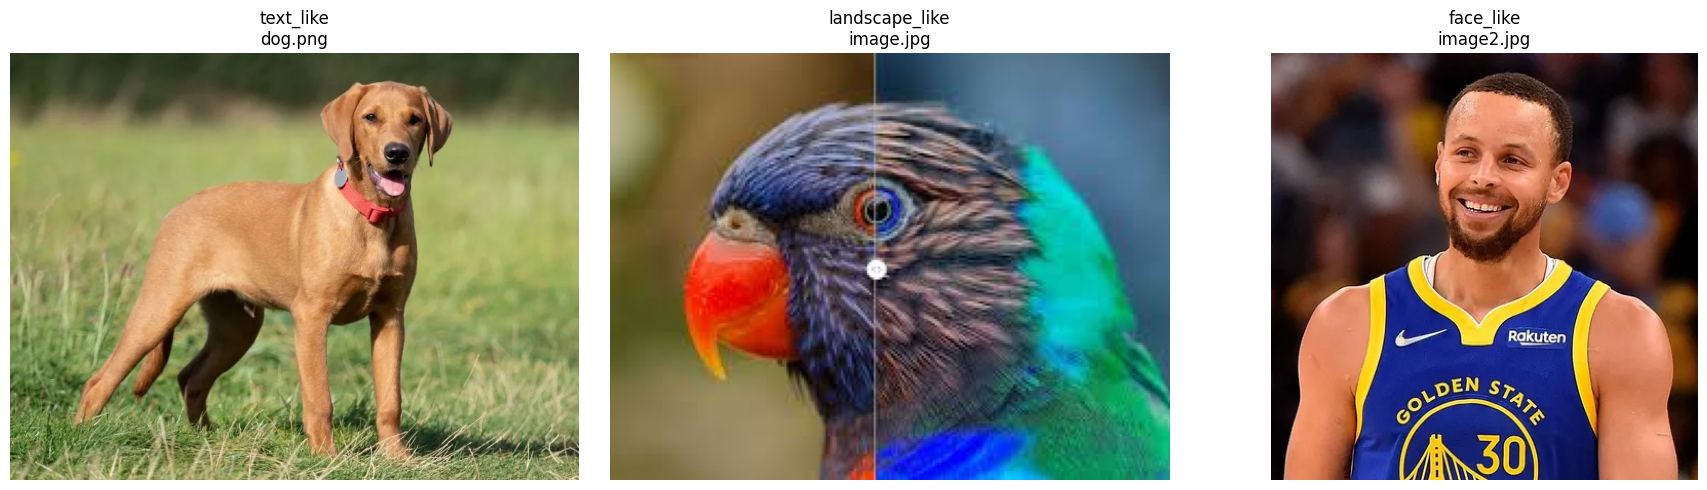

In [13]:
images_dir = "images"
category_candidates = {
    "text_like": ["dog.png", "checkerboard.jpg", "gradient.png"],
    "landscape_like": ["image.jpg", "composite_result.jpg", "blended_images.jpg"],
    "face_like": ["image2.jpg", "original_portrait.png", "dog.png"],
}

loaded = {}
for category, names in category_candidates.items():
    selected = None
    for name in names:
        p = os.path.join(images_dir, name)
        if os.path.exists(p):
            selected = p
            break
    if selected is None:
        raise FileNotFoundError(f"No image found for category: {category}")

    img_bgr = cv2.imread(selected)
    if img_bgr is None:
        raise ValueError(f"Could not read image: {selected}")

    loaded[category] = {
        "path": selected,
        "bgr": img_bgr,
        "rgb": cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB),
        "gray": cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY),
    }

print("Loaded images:")
for cat, item in loaded.items():
    print(f"- {cat}: {item['path']}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (cat, item) in zip(axes, loaded.items()):
    ax.imshow(item["rgb"])
    ax.set_title(f"{cat}\n{os.path.basename(item['path'])}")
    ax.axis("off")
plt.tight_layout()
plt.show()

## Step 2: Canny Edge Detection with Different Threshold Pairs

Threshold pairs used: (50,150), (100,200), and (150,300).

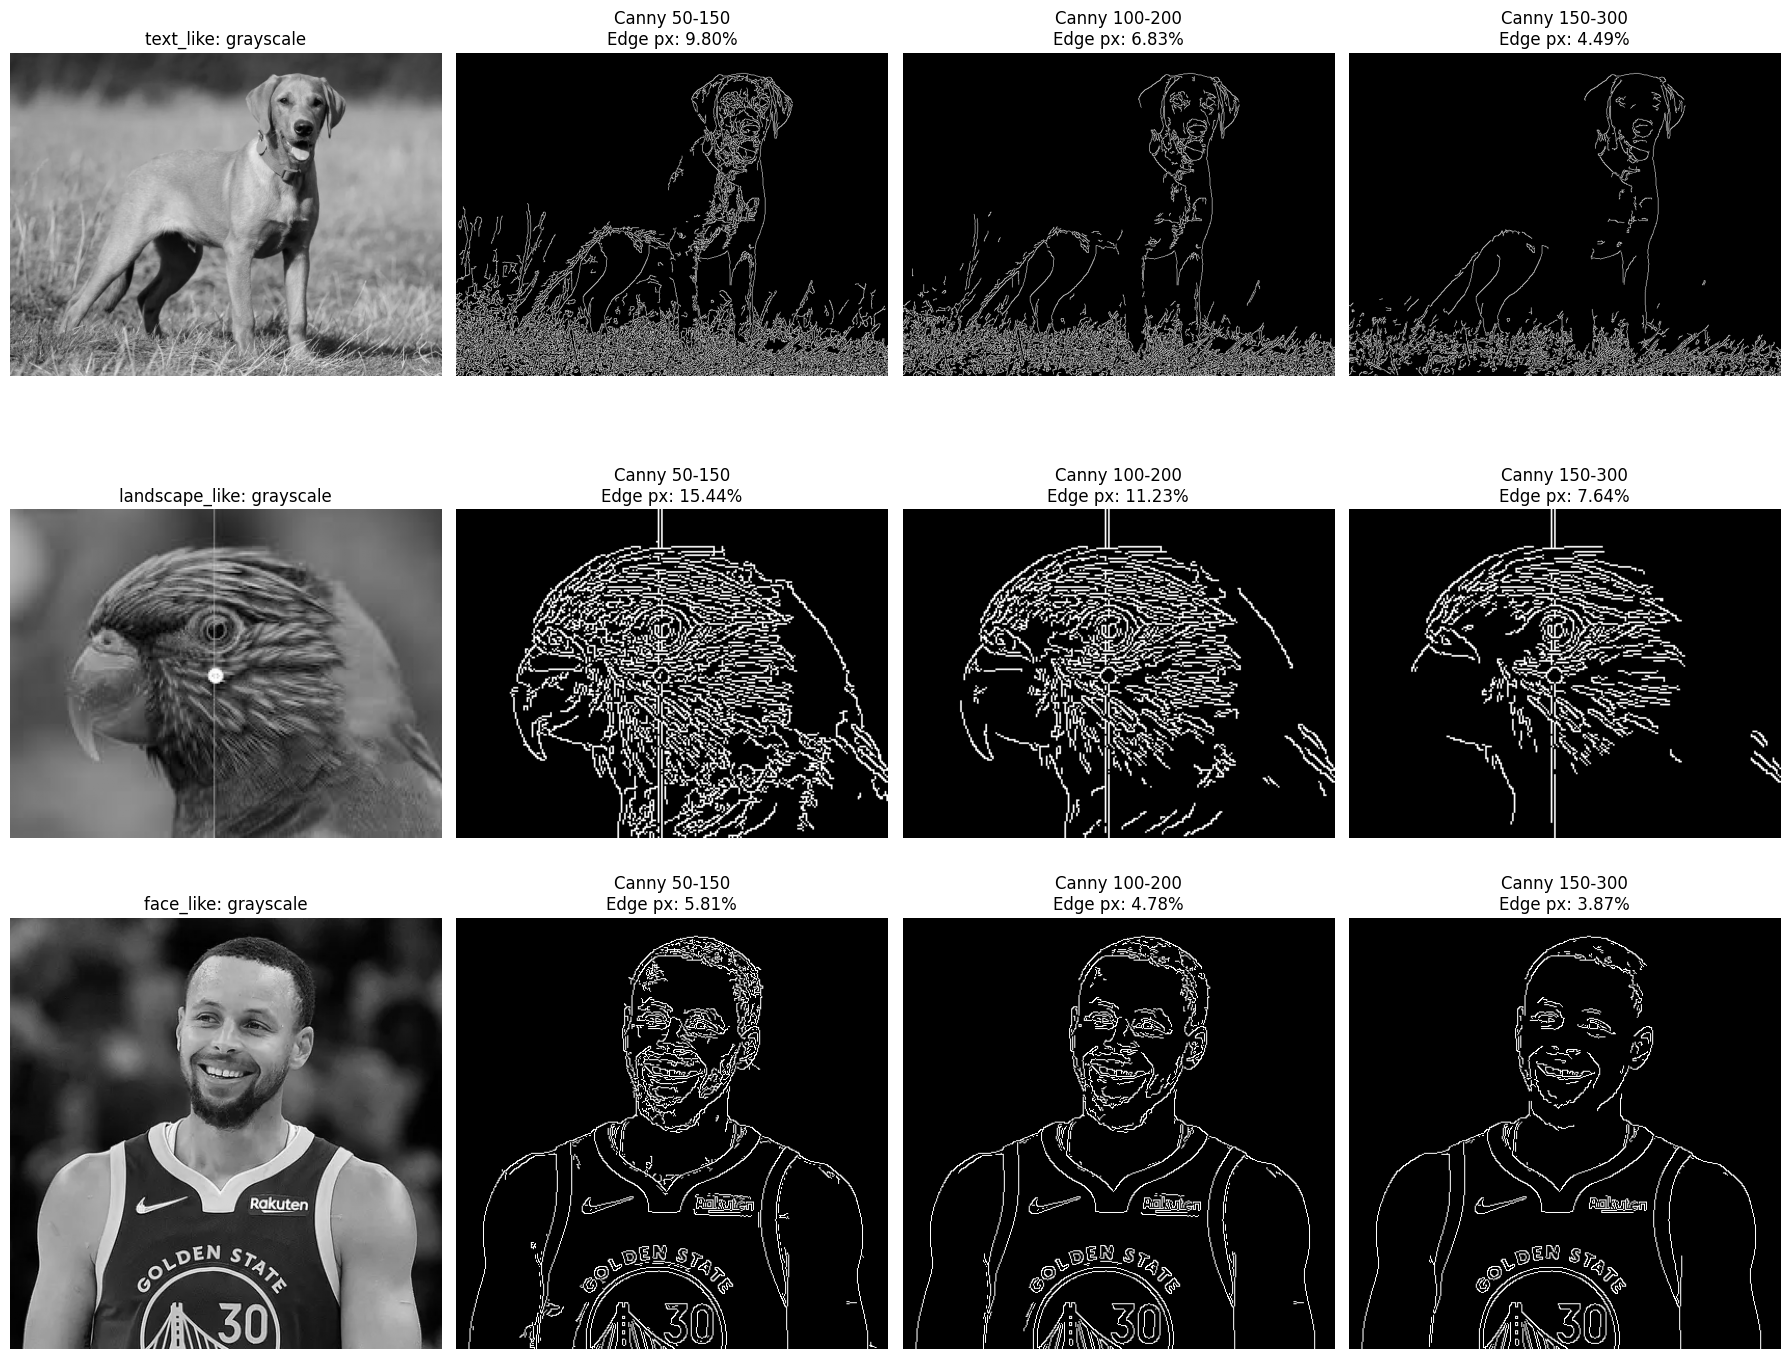

In [14]:
threshold_pairs = [(50, 150), (100, 200), (150, 300)]
canny_results = {cat: {} for cat in loaded.keys()}

fig, axes = plt.subplots(3, 4, figsize=(18, 14))
for row, (cat, item) in enumerate(loaded.items()):
    gray = item["gray"]

    axes[row, 0].imshow(gray, cmap="gray")
    axes[row, 0].set_title(f"{cat}: grayscale")
    axes[row, 0].axis("off")

    for col, (low, high) in enumerate(threshold_pairs, start=1):
        edges = cv2.Canny(gray, low, high)
        canny_results[cat][(low, high)] = edges
        edge_ratio = (np.count_nonzero(edges) / edges.size) * 100

        axes[row, col].imshow(edges, cmap="gray")
        axes[row, col].set_title(f"Canny {low}-{high}\nEdge px: {edge_ratio:.2f}%")
        axes[row, col].axis("off")

plt.tight_layout()
plt.show()

## Step 3: Compare Canny with Sobel Edge Detection

Here, Sobel X and Sobel Y are combined and compared directly against Canny (100,200).

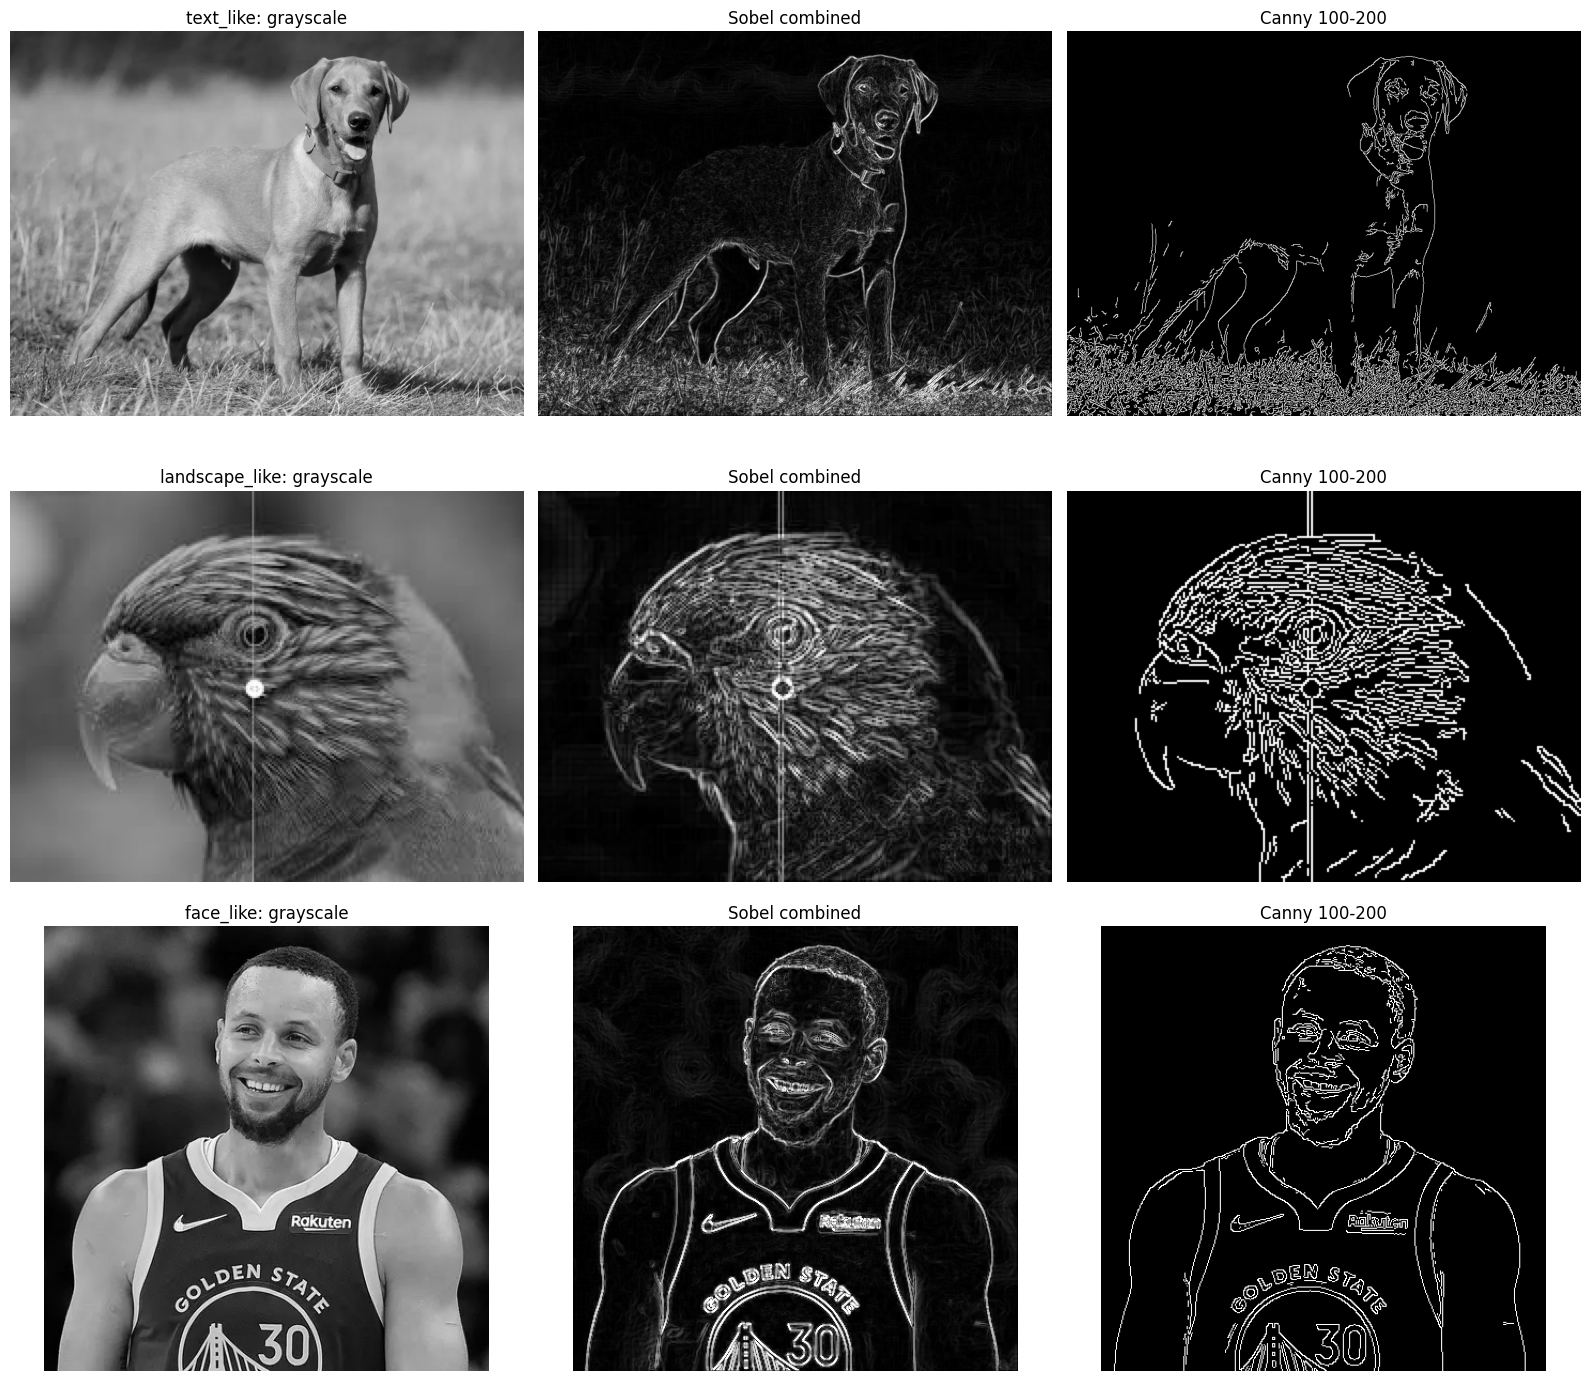

In [15]:
comparison_pair = (100, 200)
fig, axes = plt.subplots(3, 3, figsize=(16, 14))

for row, (cat, item) in enumerate(loaded.items()):
    gray = item["gray"]

    sobel_x = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
    sobel_y = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
    sobel_abs_x = cv2.convertScaleAbs(sobel_x)
    sobel_abs_y = cv2.convertScaleAbs(sobel_y)
    sobel_combined = cv2.addWeighted(sobel_abs_x, 0.5, sobel_abs_y, 0.5, 0)

    canny_ref = canny_results[cat][comparison_pair]

    axes[row, 0].imshow(gray, cmap="gray")
    axes[row, 0].set_title(f"{cat}: grayscale")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(sobel_combined, cmap="gray")
    axes[row, 1].set_title("Sobel combined")
    axes[row, 1].axis("off")

    axes[row, 2].imshow(canny_ref, cmap="gray")
    axes[row, 2].set_title(f"Canny {comparison_pair[0]}-{comparison_pair[1]}")
    axes[row, 2].axis("off")

plt.tight_layout()
plt.show()

## Step 4: Dynamic Threshold UI with OpenCV Trackbars

This code provides an interactive UI for Canny threshold tuning using trackbars.

Instructions:
- Run the cell.
- A window named `Canny Trackbar UI` opens.
- Adjust `Lower` and `Upper` sliders.
- Press `q` to close the window.

In [16]:
def launch_canny_trackbar_ui(category="face_like", start_low=100, start_high=200):
    if category not in loaded:
        raise ValueError(f"Category must be one of: {list(loaded.keys())}")

    gray = loaded[category]["gray"]
    window = "Canny Trackbar UI"

    def _nothing(_):
        pass

    cv2.namedWindow(window, cv2.WINDOW_NORMAL)
    cv2.createTrackbar("Lower", window, int(start_low), 500, _nothing)
    cv2.createTrackbar("Upper", window, int(start_high), 500, _nothing)

    while True:
        low = cv2.getTrackbarPos("Lower", window)
        high = cv2.getTrackbarPos("Upper", window)

        if high <= low:
            high = low + 1

        edges = cv2.Canny(gray, low, high)
        stacked = np.hstack([gray, edges])

        cv2.imshow(window, stacked)
        key = cv2.waitKey(1) & 0xFF
        if key == ord("q"):
            break

    cv2.destroyWindow(window)

print("Trackbar UI function is ready.")
print("Run: launch_canny_trackbar_ui('face_like', 100, 200)")

Trackbar UI function is ready.
Run: launch_canny_trackbar_ui('face_like', 100, 200)


## Results and Discussion

- For text-like patterns, Canny usually produced cleaner thin edges than Sobel.
- For landscape-like content, lower thresholds captured more texture, while higher thresholds reduced clutter.
- For face-like content, the middle pair (100,200) gave a good balance between useful facial boundaries and noise suppression.
- Sobel responded strongly to gradient changes, but Canny gave more controlled final edge maps because of thresholding and non-maximum suppression.

From the experiments, threshold choice depends on image content, and an interactive UI helps fine-tune the best values.

## Conclusion

All Lab 2 requirements were completed:
- Multiple images were loaded and processed with Canny.
- Three threshold pairs were tested and compared.
- Canny outputs were compared with Sobel edge detection.
- A dynamic threshold-adjustment interface was implemented using OpenCV trackbars.

This notebook demonstrates both experimental comparison and practical parameter tuning for edge detection.